# Sequential Bayesian Test — Paired (Laplace)

Demo of `SequentialPairedBayesPropTest` from `bayesprop.resources.bayes_paired_laplace`.

Paired binary observations from two arms **A** and **B** arrive in batches. The pooled Bernoulli logistic model

$$
y_{A,i}\sim\text{Bernoulli}(\sigma(\mu+\delta_A)),\qquad
y_{B,i}\sim\text{Bernoulli}(\sigma(\mu))
$$

depends on the data **only** through the four sufficient statistics $(n_A, k_A, n_B, k_B)$. After each batch we update those counts and re-apply the Laplace approximation to the cumulative log-posterior:

1. find the new MAP $\hat\theta_t$ of $\log p_t(\mu,\delta_A)$ by L-BFGS in 2D,
2. evaluate the closed-form $2\times2$ Hessian $H_t$ at the MAP,
3. take $\Sigma_t = H_t^{-1}$ (closed-form $2\times2$ inverse).

This is equivalent to a one-shot fit on all accumulated data — streaming introduces **no** additional approximation on top of the Laplace step. We stop as soon as the Savage–Dickey $\text{BF}_{10}$ crosses an upper or lower threshold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bayesprop.resources.bayes_paired_laplace import (
    SequentialPairedBayesPropTest,
    PairedBayesPropTest,
)

rng = np.random.default_rng(42)

## 1. Simulate a paired Bernoulli stream

Ground truth on the logit scale: $\mu = 0.5$, $\delta_A = 0.6$. We sample a per-item nuisance effect $z_i\sim\mathcal{N}(0,1)$ shared by both arms (mimicking item difficulty), so the pair is correlated. Each look delivers a batch of 25 paired observations.

In [2]:
mu_true, delta_true = 0.5, 0.6
batch_size = 25
n_batches_max = 40

def stream():
    """Yield paired (y_a_batch, y_b_batch) batches of binary observations."""
    for _ in range(n_batches_max):
        z = rng.normal(0.0, 1.0, size=batch_size)
        p_a = 1.0 / (1.0 + np.exp(-(mu_true + delta_true + z)))
        p_b = 1.0 / (1.0 + np.exp(-(mu_true + z)))
        y_a = (rng.random(batch_size) < p_a).astype(int)
        y_b = (rng.random(batch_size) < p_b).astype(int)
        yield y_a, y_b

## 2. Configure the sequential test

- Prior $\delta_A\sim\mathcal{N}(0,1)$ (kept fixed across all looks so Savage–Dickey BF is consistent).
- Stop for $H_1$ when $\text{BF}_{10}\ge 10$, stop for $H_0$ when $\text{BF}_{10}\le 0.1$.
- `n_min = 30` per arm before BF-based stopping (guards against unstable early BFs).
- Hard cap `n_max = 1000`.
- ROPE half-width $\varepsilon=0.02$ on $\Delta = p_A - p_B$ (probability scale).

In [3]:
seq = SequentialPairedBayesPropTest(
    prior_sigma_delta=1.0,
    bf_upper=10.0,
    bf_lower=0.1,
    n_min=30,
    n_max=1000,
    rope_epsilon=0.02,
    seed=0,
    n_samples=8000,
    verbose=True,
)

## 3. Run the test on the stream

`update()` accumulates the new counts, re-fits the Laplace posterior in closed form, and returns a snapshot.

In [4]:
final = seq.run(stream())

print("\nStopped:", seq.stopped)
print("Reason :", seq.stop_reason)
print("Looks  :", len(seq.history))
print("Final n per arm:", final.n_A, final.n_B)

[look 1] n_A=25 n_B=25 P(A>B)=0.427 BF10=0.568 stop=False (None)
[look 2] n_A=50 n_B=50 P(A>B)=0.684 BF10=0.465 stop=False (None)
[look 3] n_A=75 n_B=75 P(A>B)=0.647 BF10=0.364 stop=False (None)
[look 4] n_A=100 n_B=100 P(A>B)=0.915 BF10=0.761 stop=False (None)
[look 5] n_A=125 n_B=125 P(A>B)=0.950 BF10=1.01 stop=False (None)
[look 6] n_A=150 n_B=150 P(A>B)=0.967 BF10=1.37 stop=False (None)
[look 7] n_A=175 n_B=175 P(A>B)=0.990 BF10=3.9 stop=False (None)
[look 8] n_A=200 n_B=200 P(A>B)=0.991 BF10=4.31 stop=False (None)
[look 9] n_A=225 n_B=225 P(A>B)=0.994 BF10=6.03 stop=False (None)
[look 10] n_A=250 n_B=250 P(A>B)=0.993 BF10=4.91 stop=False (None)
[look 11] n_A=275 n_B=275 P(A>B)=0.997 BF10=6.64 stop=False (None)
[look 12] n_A=300 n_B=300 P(A>B)=0.992 BF10=4 stop=False (None)
[look 13] n_A=325 n_B=325 P(A>B)=0.986 BF10=1.96 stop=False (None)
[look 14] n_A=350 n_B=350 P(A>B)=0.976 BF10=1.18 stop=False (None)
[look 15] n_A=375 n_B=375 P(A>B)=0.990 BF10=2.58 stop=False (None)
[look 16] 

## 4. Inspect the final snapshot

The last `SequentialLaplaceLookResult` carries:

- `posterior_state.mu_map`, `delta_A_map`, `cov` — Laplace posterior on the logit scale
- `P_A_greater_B` — $P(p_A > p_B)$ on the probability scale
- `decision.bayes_factor` — Savage–Dickey BF on $\delta_A = 0$
- `decision.rope` — ROPE classification on $\Delta = p_A - p_B$

In [5]:
ps = final.posterior_state
print("Laplace posterior (logit scale):")
print(f"  mu_MAP      = {ps.mu_map:+.4f}")
print(f"  delta_A_MAP = {ps.delta_A_map:+.4f}")
print(f"  cov         = {np.asarray(ps.cov)}")

print(f"\nP(p_A > p_B) = {final.P_A_greater_B:.4f}")

bf = final.decision.bayes_factor
print(f"\nSavage-Dickey BF_10 = {bf.BF_10:.3g}")
print(f"Savage-Dickey BF_01 = {bf.BF_01:.3g}")
print(f"Interpretation     : {bf.interpretation}")
print(f"Decision           : {bf.decision}")

rope = final.decision.rope
print(f"\nROPE [{rope.rope_lower:+.2f}, {rope.rope_upper:+.2f}]")
print(f"  95% CI on Delta: [{rope.ci_lower:+.3f}, {rope.ci_upper:+.3f}]")
print(f"  pct in ROPE    : {rope.pct_in_rope:.3f}")
print(f"  decision       : {rope.decision}")

Laplace posterior (logit scale):
  mu_MAP      = +0.4348
  delta_A_MAP = +0.4433
  cov         = [[ 0.00872984 -0.00864211]
 [-0.00864211  0.01860474]]

P(p_A > p_B) = 0.9992

Savage-Dickey BF_10 = 18.6
Savage-Dickey BF_01 = 0.0537
Interpretation     : Strong evidence against H0
Decision           : Reject H0

ROPE [-0.02, +0.02]
  95% CI on Delta: [+0.039, +0.158]
  pct in ROPE    : 0.006
  decision       : Reject H0 — A practically better


## 5. Per-look history

In [6]:
df = seq.history_frame()
df

,look,n_A,n_B,mu_MAP,delta_A_MAP,P_A_gt_B,BF_10,BF_01,pct_in_rope,stop,stop_reason
0,1,25,25,1.072211,-0.106516,0.426625,0.567883,1.760926,0.146750,False,NaN
1,2,50,50,0.940158,0.191623,0.684000,0.465383,2.148766,0.178250,False,NaN
2,3,75,75,0.810898,0.125292,0.647125,0.364276,2.745169,0.211500,False,NaN
3,4,100,100,0.673783,0.403427,0.915125,0.760590,1.314769,0.100625,False,NaN
4,5,125,125,0.619886,0.429036,0.949750,1.014020,0.986174,0.074750,False,NaN
5,6,150,150,0.555240,0.441367,0.966500,1.368009,0.730989,0.056875,False,NaN
6,7,175,175,0.536011,0.538707,0.990375,3.899797,0.256424,0.021375,False,NaN
7,8,200,200,0.540441,0.518090,0.991250,4.305656,0.232253,0.021000,False,NaN
8,9,225,225,0.469096,0.530482,0.994375,6.033031,0.165754,0.014125,False,NaN
9,10,250,250,0.512605,0.482375,0.992750,4.905948,0.203834,0.018500,False,NaN


## 6. Trajectory plot

$\text{BF}_{10}$ (log scale) and $P(p_A > p_B)$ vs cumulative sample size, with stopping thresholds drawn as dashed lines.

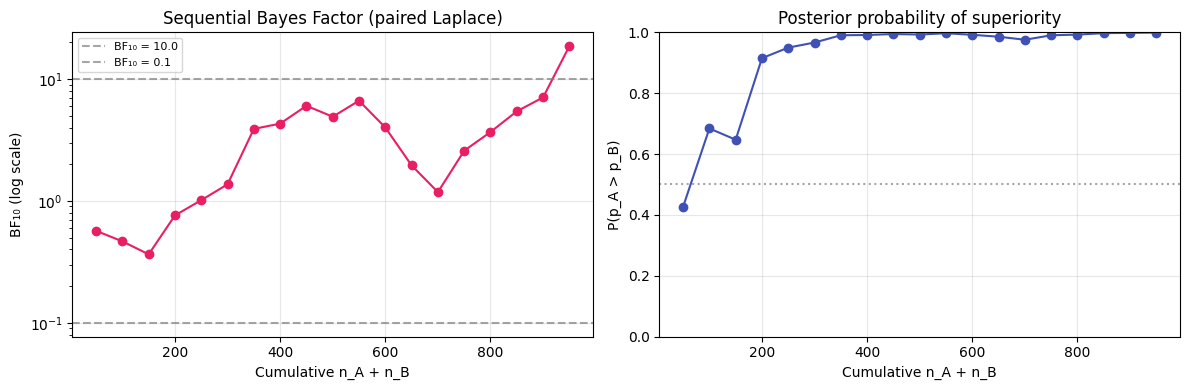

In [7]:
seq.plot_trajectory()

## 7. Sanity check: sequential = single-shot

Because the likelihood depends only on the four sufficient statistics, fitting the cumulative data in one shot must produce **the same** Laplace posterior as the running sequential update.

In [8]:
y_a_all = np.r_[np.ones(final.successes_A, dtype=int), np.zeros(final.n_A - final.successes_A, dtype=int)]
y_b_all = np.r_[np.ones(final.successes_B, dtype=int), np.zeros(final.n_B - final.successes_B, dtype=int)]

batch = PairedBayesPropTest(prior_sigma_delta=1.0, seed=0, n_samples=8000).fit(y_a_all, y_b_all)

print("Sequential MAP : mu=%+.6f  delta_A=%+.6f" % (final.posterior_state.mu_map, final.posterior_state.delta_A_map))
print("Single-shot MAP: mu=%+.6f  delta_A=%+.6f" % (batch.laplace['map'][0], batch.laplace['map'][1]))

print("\nSequential cov:\n", np.asarray(final.posterior_state.cov))
print("\nSingle-shot cov:\n", batch.laplace['cov'])

Sequential MAP : mu=+0.434804  delta_A=+0.443328
Single-shot MAP: mu=+0.434804  delta_A=+0.443328

Sequential cov:
 [[ 0.00872984 -0.00864211]
 [-0.00864211  0.01860474]]

Single-shot cov:
 [[ 0.00872984 -0.00864211]
 [-0.00864211  0.01860474]]
